In [ ]:
import pandas as pd
import numpy as np
import os                   
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("data/boston.csv")
print(df)


    Beszerzési ár  Eladási ár
0           37437       57764
1           57389       81142
2           68038       68439
3           74513       73124
4           26926       43609
5           96316      126799
6           32862       45820
7           40446       45453
8           19789       26792
9           76664      111568
10          44417       59180
11          50355       77006
12          53757       75434
13          53641       76945
14          11229       21402
15          72260       72746
16          63709       61960
17          31916       51430
18          18712       34321
19          88030       89135


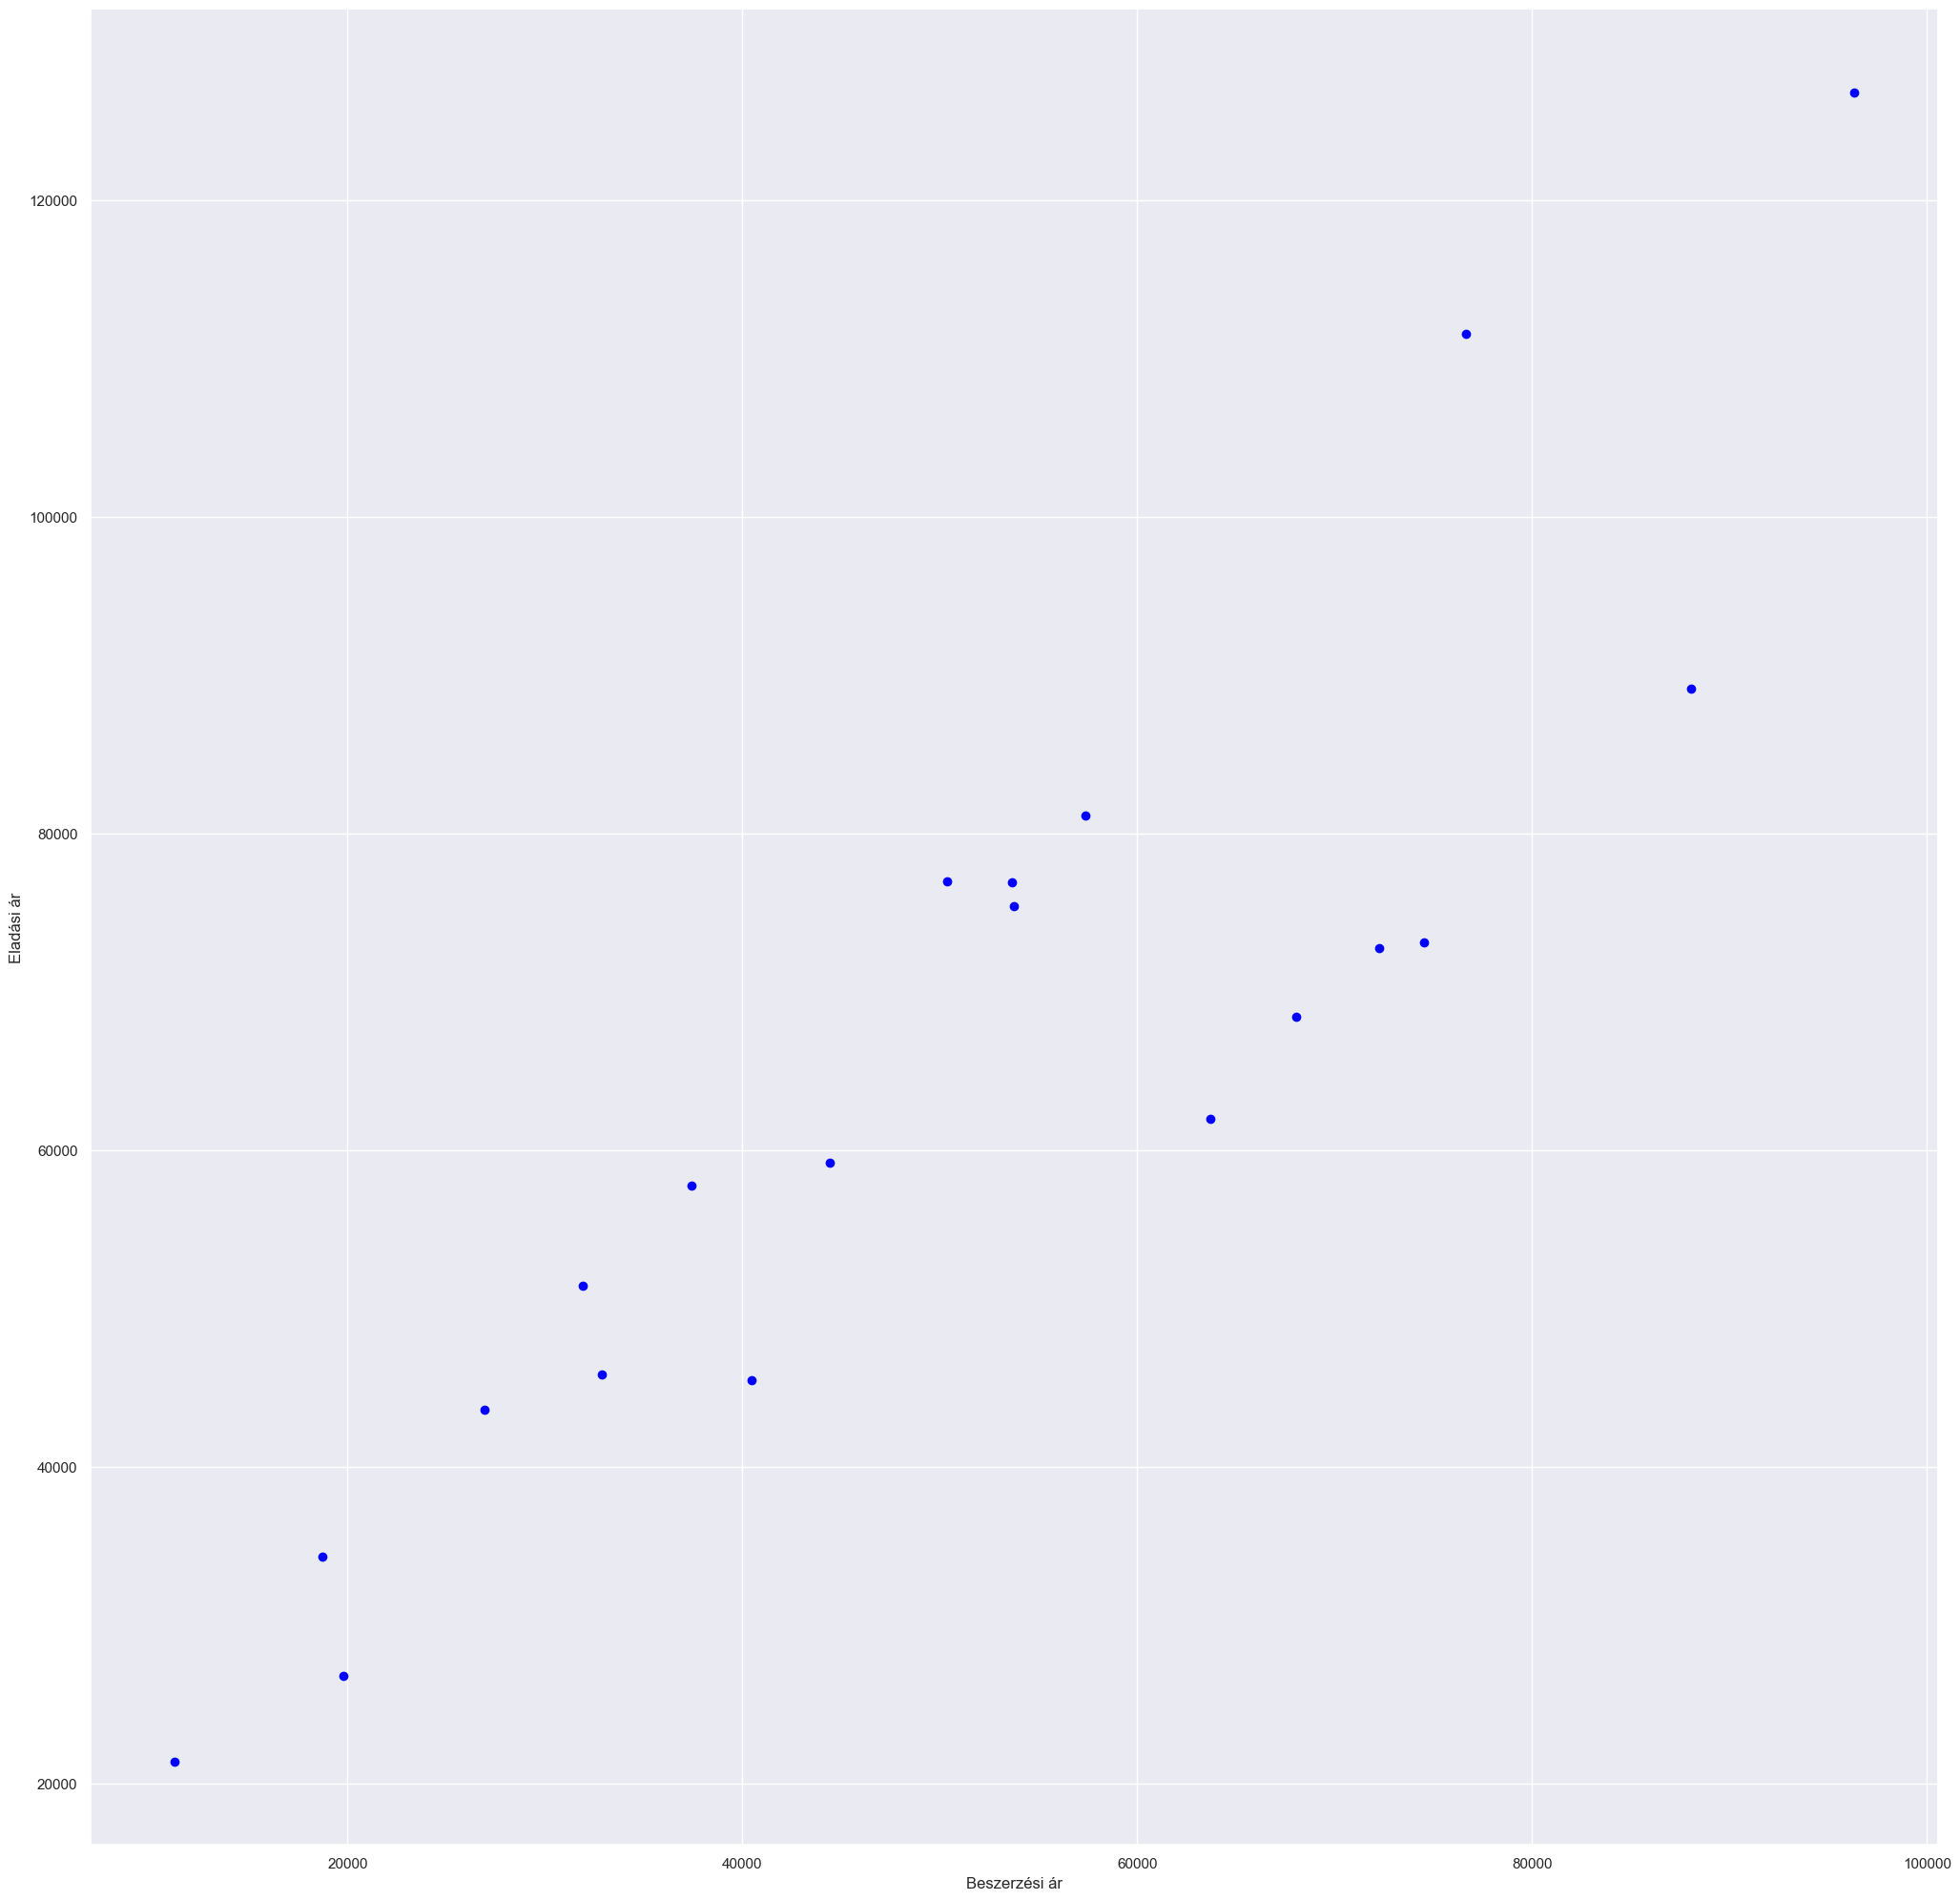

In [34]:
# Kirajzoljuk a pontokat
import matplotlib.pyplot as plt
%matplotlib inline
plt.scatter(df['Beszerzési ár'], df['Eladási ár'],  color='blue')
plt.xlabel("Beszerzési ár")
plt.ylabel("Eladási ár")
plt.show()

In [35]:
df.describe()

,Beszerzési ár,Eladási ár
count,20.000000,20.000000
mean,50920.300000,65003.450000
std,23847.698815,26311.162531
min,11229.000000,21402.000000
25%,32625.500000,45728.250000
50%,51998.000000,65199.500000
75%,69093.500000,76960.250000
max,96316.000000,126799.000000


In [36]:
# dataframe oszlopok átalakítása numpy tömbbé
x = np.asanyarray(df[['Beszerzési ár']])
y = np.asanyarray(df[['Eladási ár']])

In [37]:
from sklearn.linear_model import LinearRegression  # lineáris regressziós eljárás beimportálása
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score  # mutatószámok számítása

In [38]:
linreg = LinearRegression()
linreg.fit(x, y)
print ('Coefficients: a =', linreg.coef_)
print ('Intercept: b = ',linreg.intercept_)

Coefficients: a = [[0.99969764]]
Intercept: b =  [14098.546376]


In [39]:
y_pred = linreg.predict(x)  # az egyenes értékeinek kiszámolása az adatpontokban - ez előrejelzet érték regresszió szerint
print(y_pred)

[[ 51524.2268408 ]
 [ 71470.19410937]
 [ 82115.97425388]
 [ 88589.01645837]
 [ 41016.40497031]
 [110385.42405444]
 [ 46950.61014805]
 [ 54532.31703282]
 [ 33881.56292962]
 [ 90739.36607719]
 [ 58502.11635236]
 [ 64438.32092537]
 [ 67839.29228903]
 [ 67723.32736305]
 [ 25324.1511504 ]
 [ 86336.6976805 ]
 [ 77788.28318001]
 [ 46004.89618273]
 [ 32804.88857375]
 [102101.92942796]]


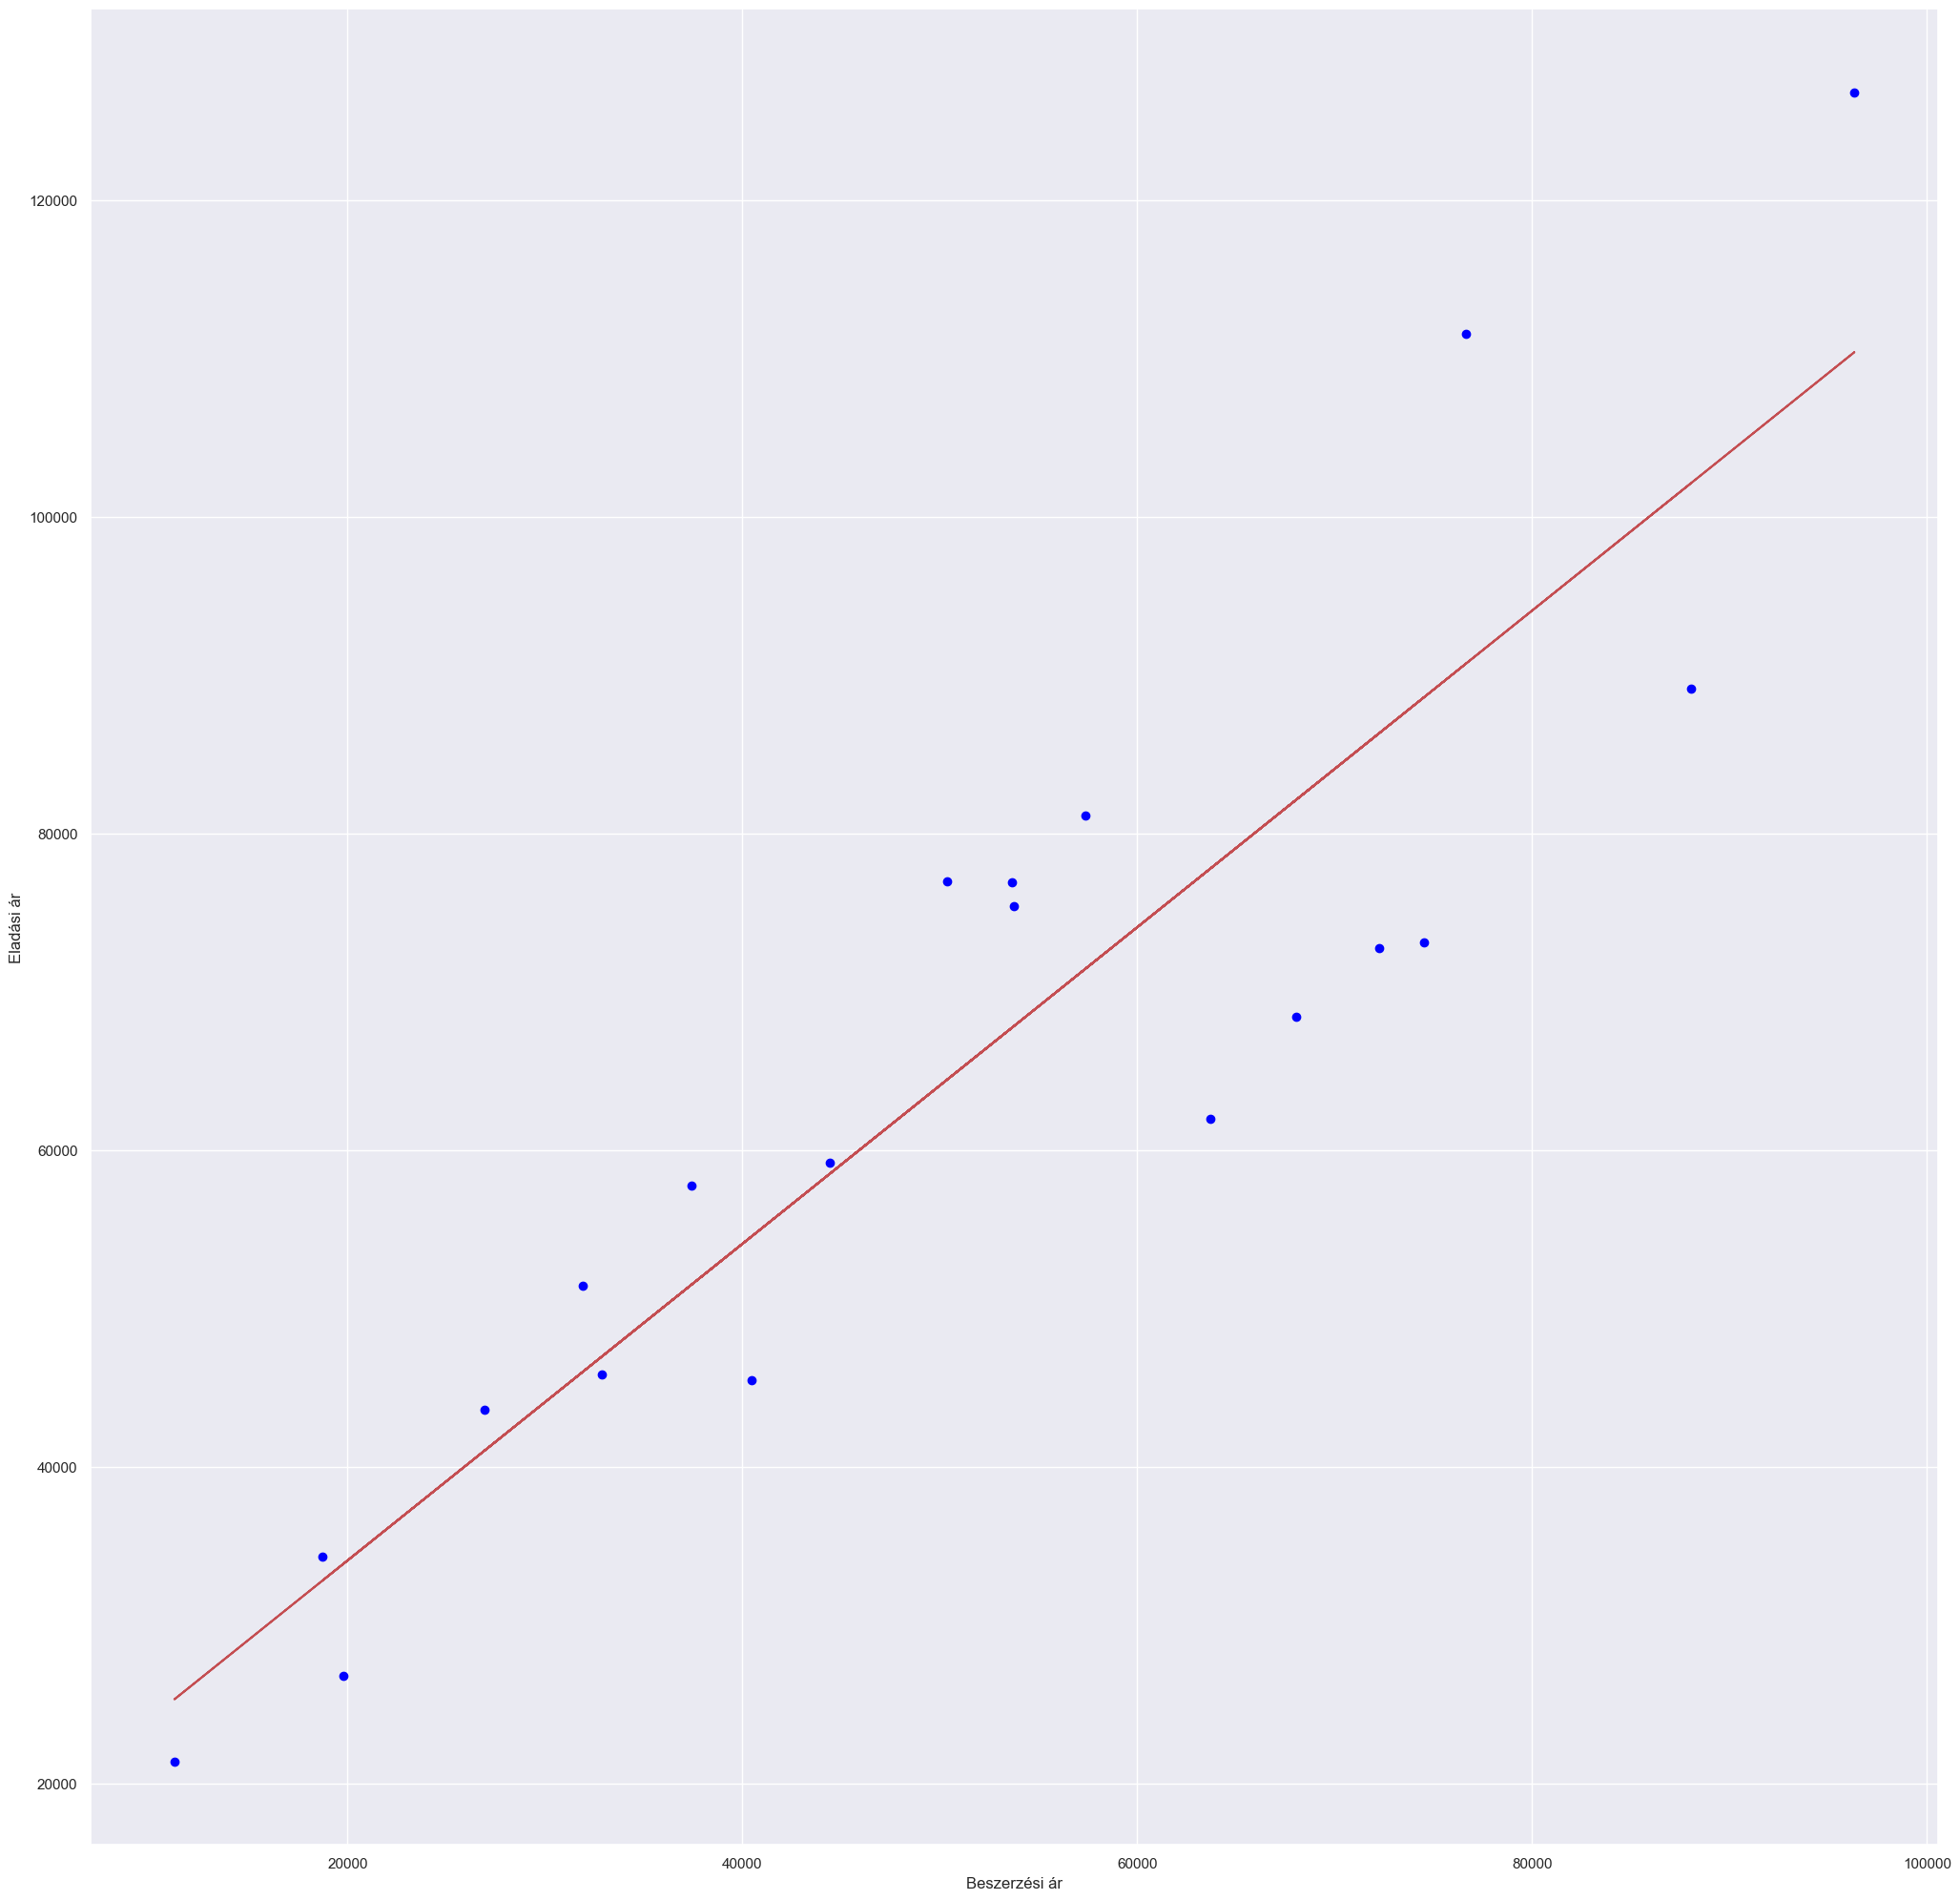

In [40]:
# A regressziós egyenes kirajzolása
plt.scatter(df['Beszerzési ár'], df['Eladási ár'],  color='blue')
plt.plot(x, linreg.coef_[0][0]*x + linreg.intercept_[0], '-r')
plt.xlabel("Beszerzési ár")
plt.ylabel("Eladási ár")
plt.show()

(506, 14) -> (268, 14)
(506, 14) -> (415, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


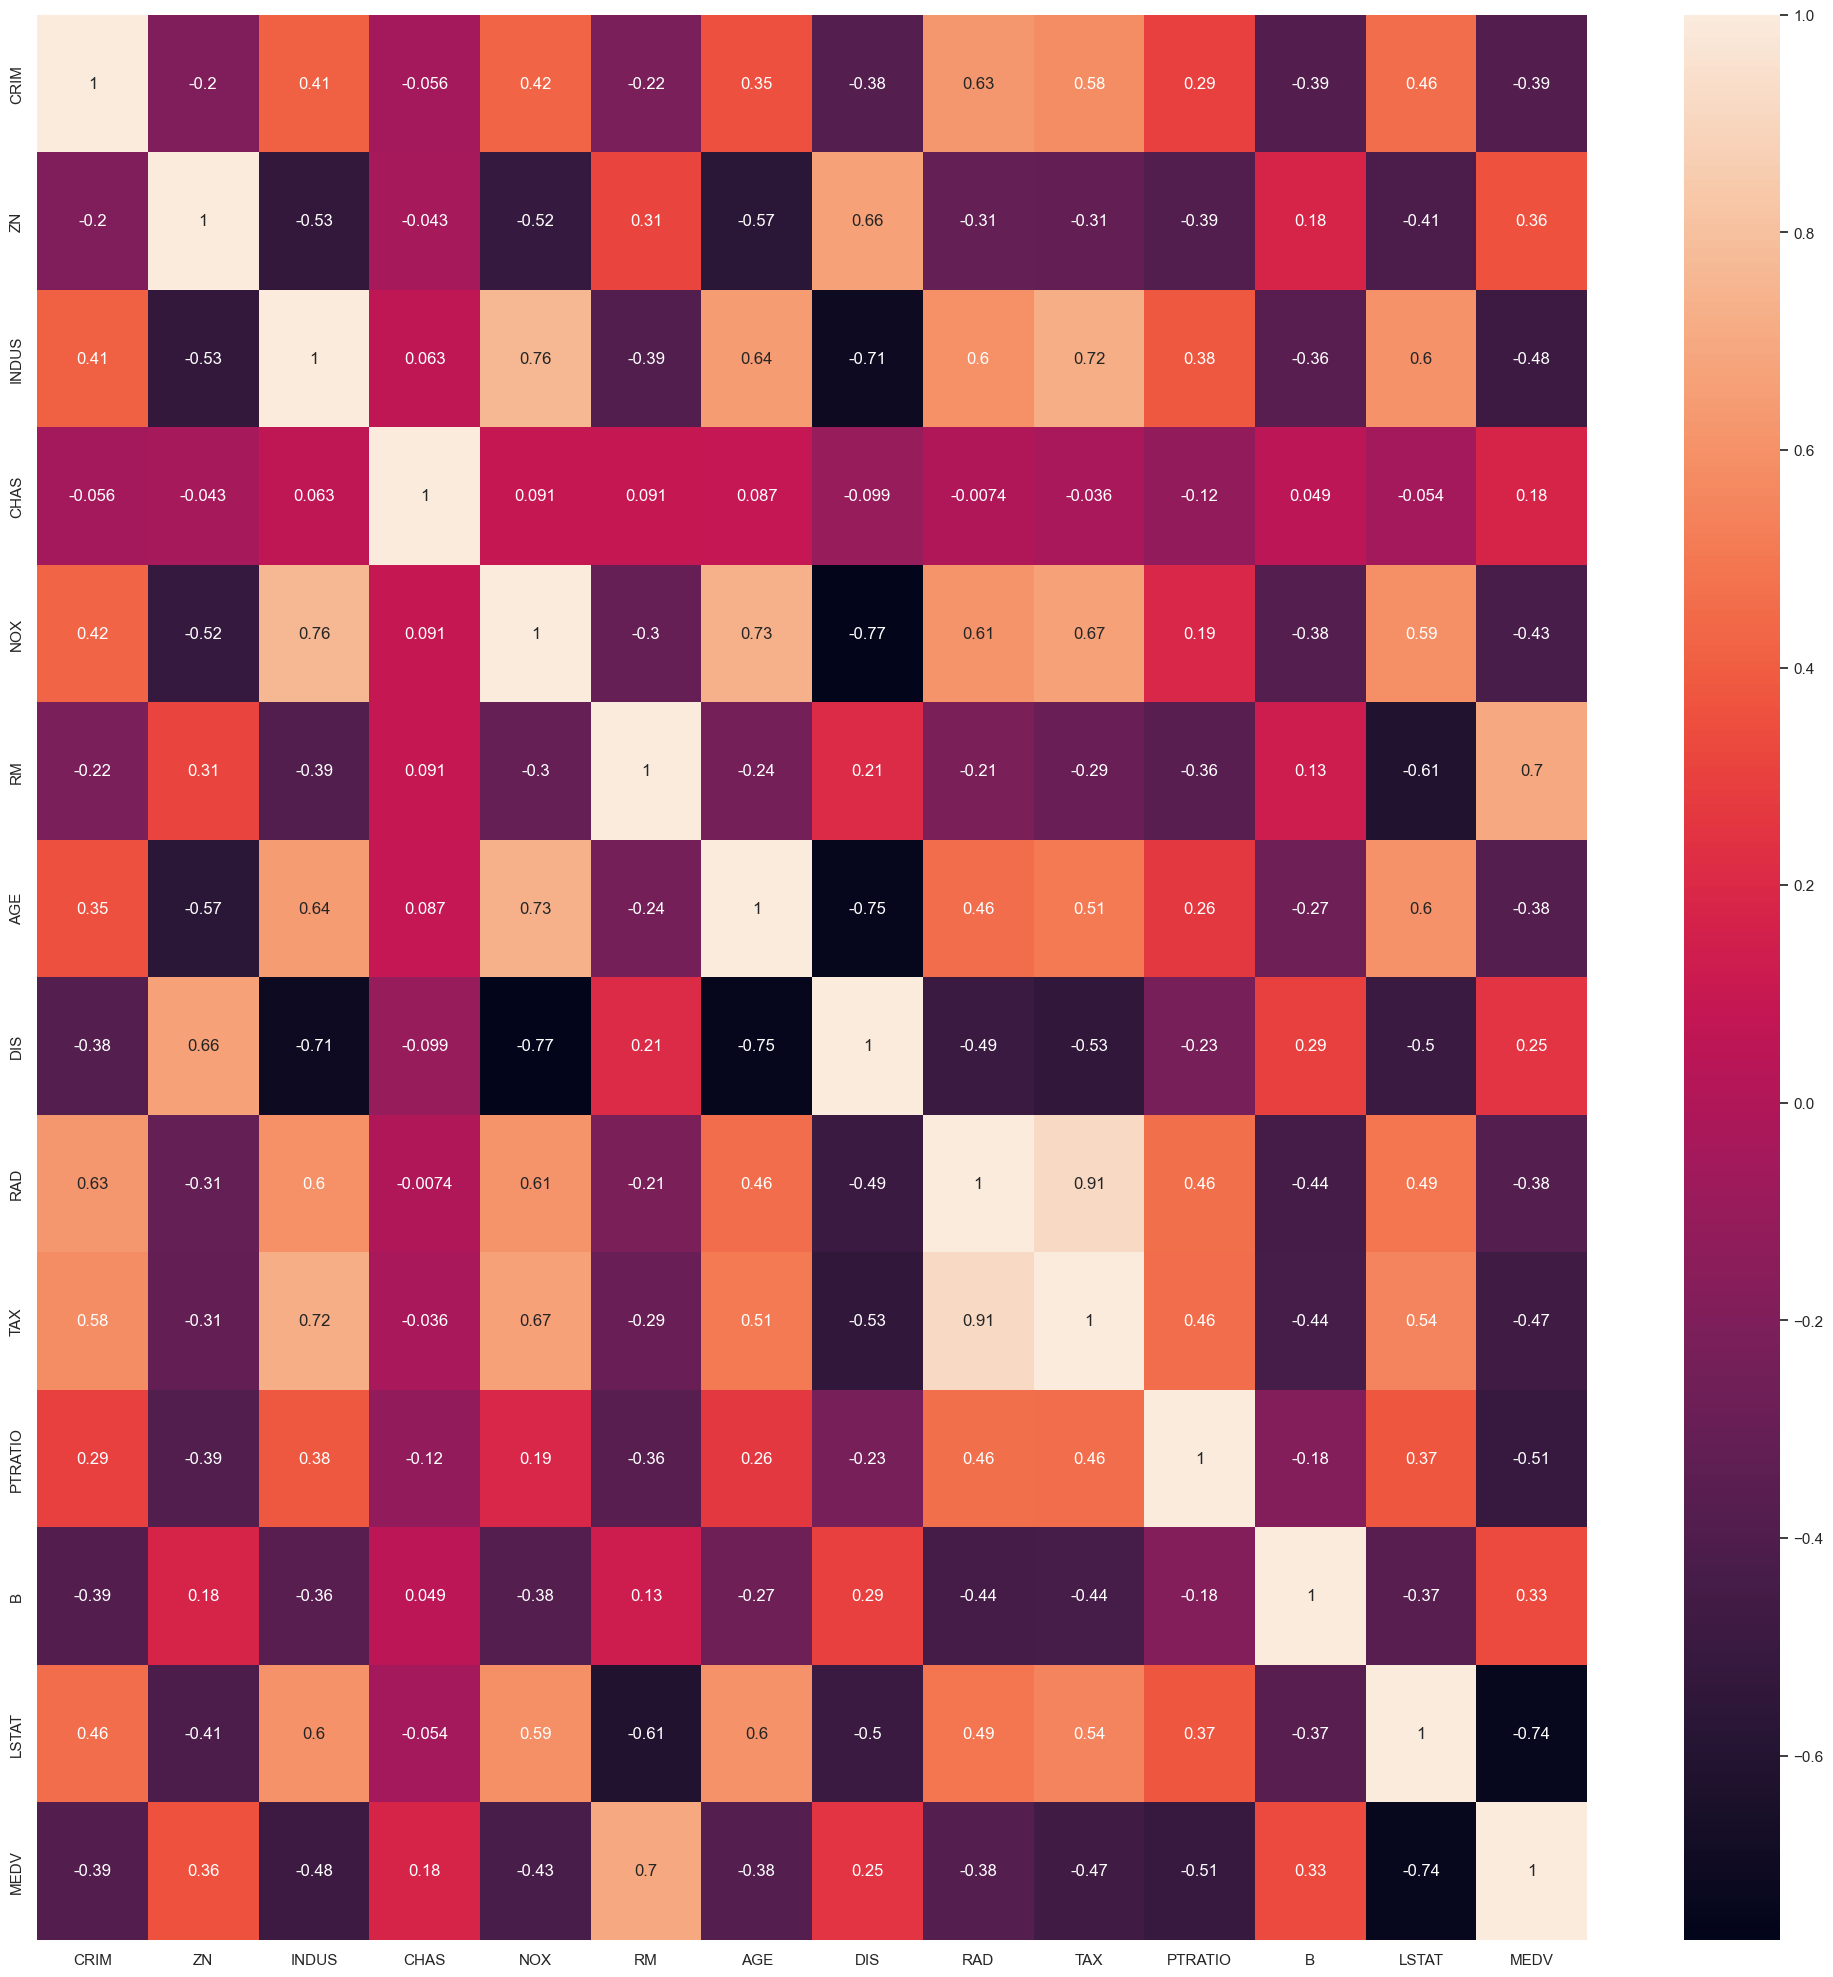

In [ ]:
df = pd.read_csv("data/boston.csv")
df
df.head()
df.isna().sum()
df.duplicated().sum()

numeric_cols = df.columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[~((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).any(axis=1)]

print(df.shape, "->", df_clean.shape)

from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df))
df_z_clean = df[(z_scores < 3).all(axis=1)]

print(df.shape, "->", df_z_clean.shape)

df.info()

heat_map = sns.heatmap(df.corr() , annot=True )
sns.set(rc = {'figure.figsize':(15,15)})
plt.show()

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

def calc_vif(df):
    X = sm.add_constant(df)
    vif_df = pd.DataFrame()
    vif_df["Változó"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                     for i in range(X.shape[1])]
    return vif_df

# 1) Eredeti VIF (RAD-dal együtt)
X1 = df_clean.drop(columns=["MEDV"])
print("VIF RAD-dal együtt:")
print(calc_vif(X1))

# 2) VIF RAD nélkül
X2 = X1.drop(columns=["RAD"])
print("\nVIF RAD nélkül:")
print(calc_vif(X2))

# 3) VIF RAD + INDUS nélkül
X3 = X1.drop(columns=["RAD", "INDUS"])
print("\nVIF RAD + INDUS nélkül:")
print(calc_vif(X3))

# 4) VIF RAD + NOX nélkül
X4 = X1.drop(columns=["RAD", "NOX"])
print("\nVIF RAD + NOX nélkül:")
print(calc_vif(X4))




VIF RAD-dal együtt:
    Változó          VIF
0     const  2162.384361
1      CRIM     6.963618
2        ZN     1.682383
3     INDUS     2.613448
4      CHAS          NaN
5       NOX     3.865442
6        RM     1.943779
7       AGE     2.442158
8       DIS     3.312497
9       RAD     9.399798
10      TAX     5.421311
11  PTRATIO     1.285263
12        B     1.082934
13    LSTAT     2.980719

VIF RAD nélkül:
    Változó          VIF
0     const  2154.215363
1      CRIM     3.182079
2        ZN     1.654858
3     INDUS     2.566891
4      CHAS          NaN
5       NOX     3.854890
6        RM     1.933988
7       AGE     2.424001
8       DIS     3.280988
9       TAX     3.439088
10  PTRATIO     1.266015
11        B     1.082700
12    LSTAT     2.971562

VIF RAD + INDUS nélkül:
    Változó          VIF
0     const  2154.173471
1      CRIM     3.130634
2        ZN     1.633281
3      CHAS          NaN
4       NOX     3.607872
5        RM     1.930745
6       AGE     2.398315
7       DIS  

In [43]:
from sklearn.model_selection import train_test_split

# X = független változók (RAD már törölve)
X = df_clean.drop(columns=["MEDV", "RAD"])
y = df_clean["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tanuló halmaz mérete:", X_train.shape)
print("Teszt halmaz mérete:", X_test.shape)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Koefficiensek:", model.coef_)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)


from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Tanuló halmaz előrejelzése
y_train_pred = model.predict(X_train)

# Teszt halmaz előrejelzése
y_test_pred = model.predict(X_test)

# R² értékek
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# RMSE értékek
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Train R²:", r2_train)
print("Test R²:", r2_test)
print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)


Tanuló halmaz mérete: (214, 12)
Teszt halmaz mérete: (54, 12)
Intercept: 11.30300637218212
Koefficiensek: [-6.45245805e-02 -1.06802612e-02 -4.90527377e-02  1.66533454e-16
 -3.53929239e-01  4.95681049e+00 -4.80691532e-02 -5.44218102e-01
 -5.22121349e-03 -6.24177870e-01  4.32012206e-03 -1.97822112e-01]
RMSE: 2.024273067620268
R²: 0.7615634196187973
Train R²: 0.6604074748255913
Test R²: 0.7615634196187973
Train RMSE: 2.817965365741976
Test RMSE: 2.024273067620268


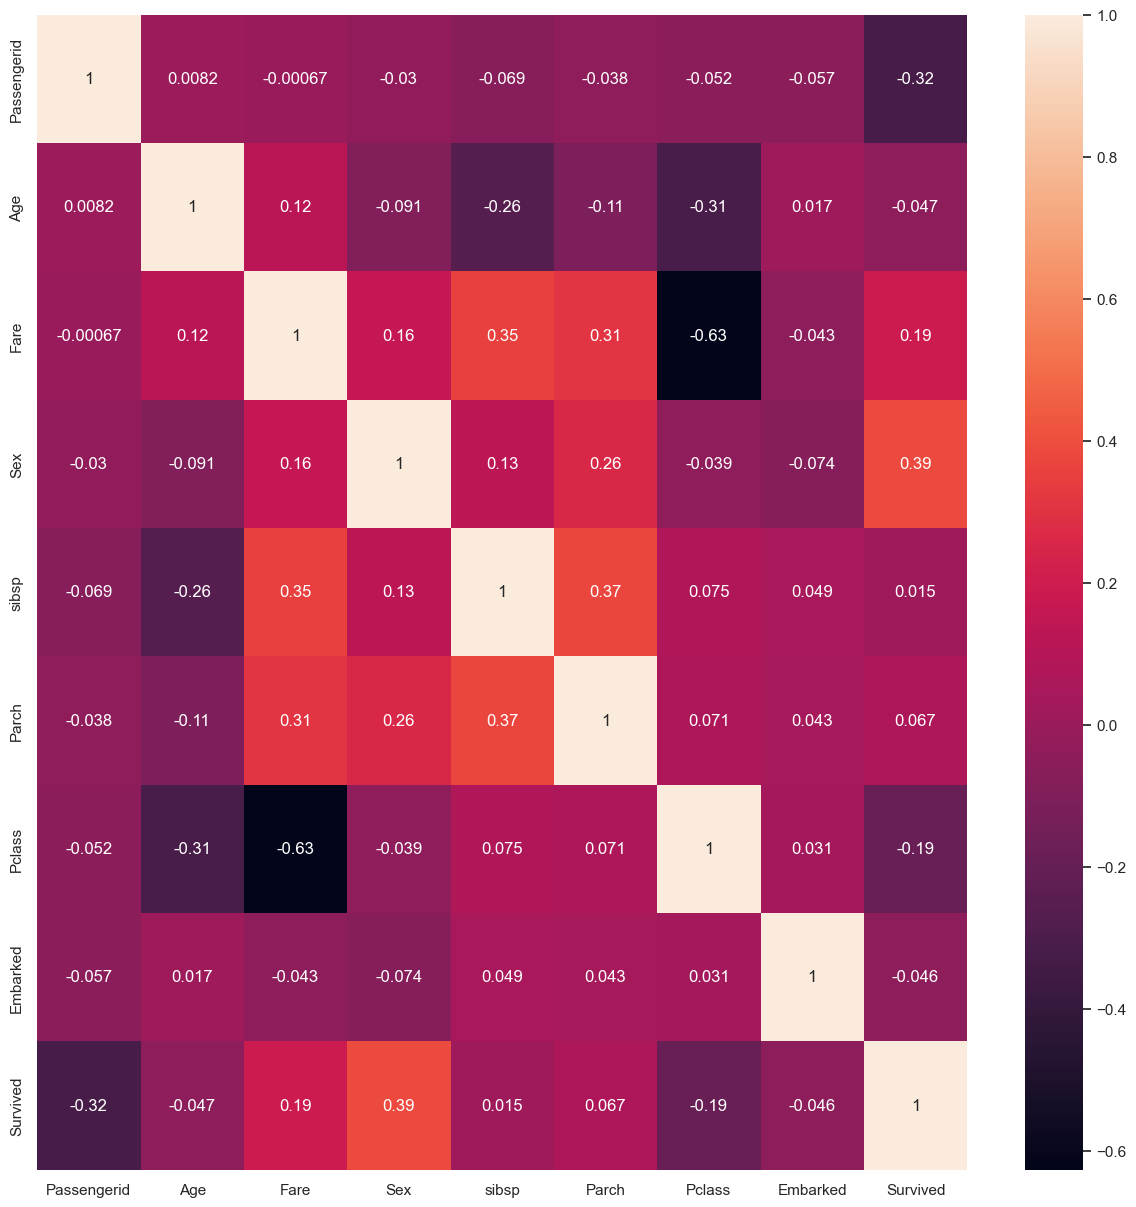

    Változó       VIF
0       Age  8.239252
1      Fare  3.918902
2       Sex  1.583589
3     sibsp  1.802284
4     Parch  1.491141
5    Pclass  7.082527
6  Embarked  4.982226


In [ ]:
df = pd.read_csv("data/boston.csv")
df.head()
df = df.dropna(subset=['Embarked'])

import numpy as np

# Outlier szűrés IQR alapján csak Age és Fare oszlopokra
for col in ['Age', 'Fare']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]


df.corr()
heat_map = sns.heatmap(df.corr() , annot=True )
sns.set(rc = {'figure.figsize':(15,15)})
plt.show()

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked']]

vif = pd.DataFrame()
vif["Változó"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)



Logisztikus regresszió CM:
 [[154   9]
 [ 27  21]]
KNN CM:
 [[144  19]
 [ 37  11]]


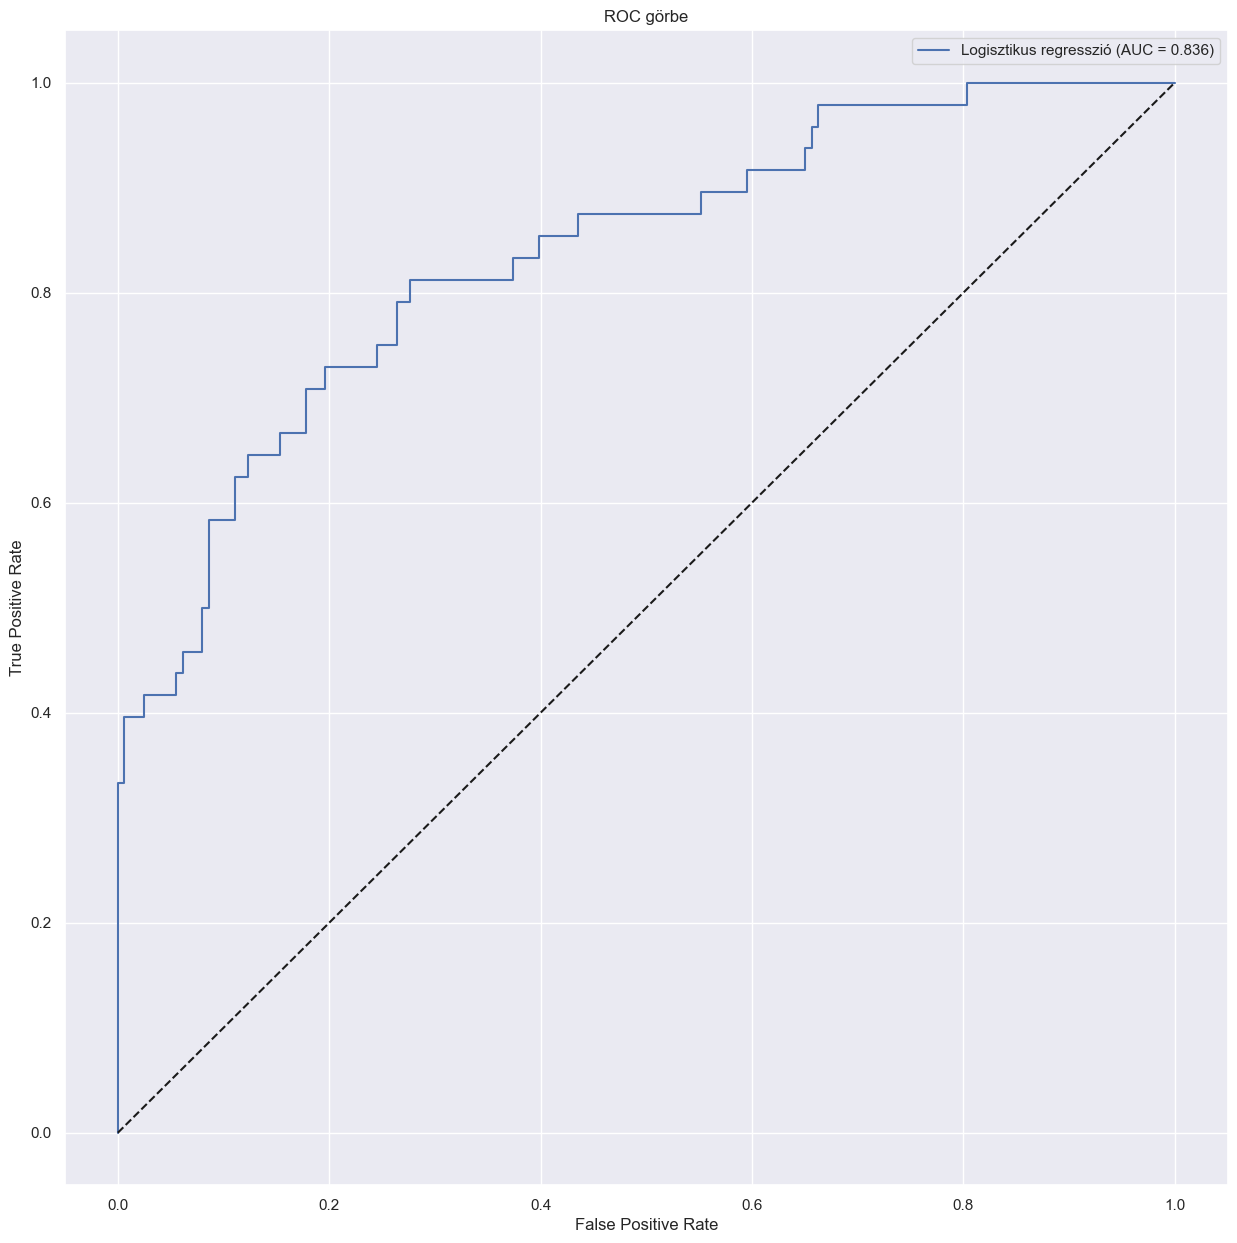

In [45]:
from sklearn.model_selection import train_test_split

# Célváltozó és független változók szétválasztása
X = df.drop('Survived', axis=1)
y = df['Survived']

# Tanuló és teszt halmaz létrehozása (80% tanuló, 20% teszt)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


y_pred_log = log_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("Logisztikus regresszió CM:\n", cm_log)
print("KNN CM:\n", cm_knn)

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_log = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

plt.plot(fpr, tpr, label=f"Logisztikus regresszió (AUC = {auc_log:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC görbe")
plt.legend()
plt.show()



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import os
df = pd.read_csv("Titanic.csv")
df.head()



,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


In [47]:
df.shape
df.info()
df.isnull().sum()  # Hol vannak hiányzó adatok
df[df.isna().any(axis=1)]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   Survived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
61,62,38.0,80.0,1,0,0,1,NaN,1
829,830,62.0,80.0,1,0,0,1,NaN,1


In [48]:
df=df.dropna()
df[df.duplicated(keep = False)]
df = df.drop(['Passengerid'], axis=1)


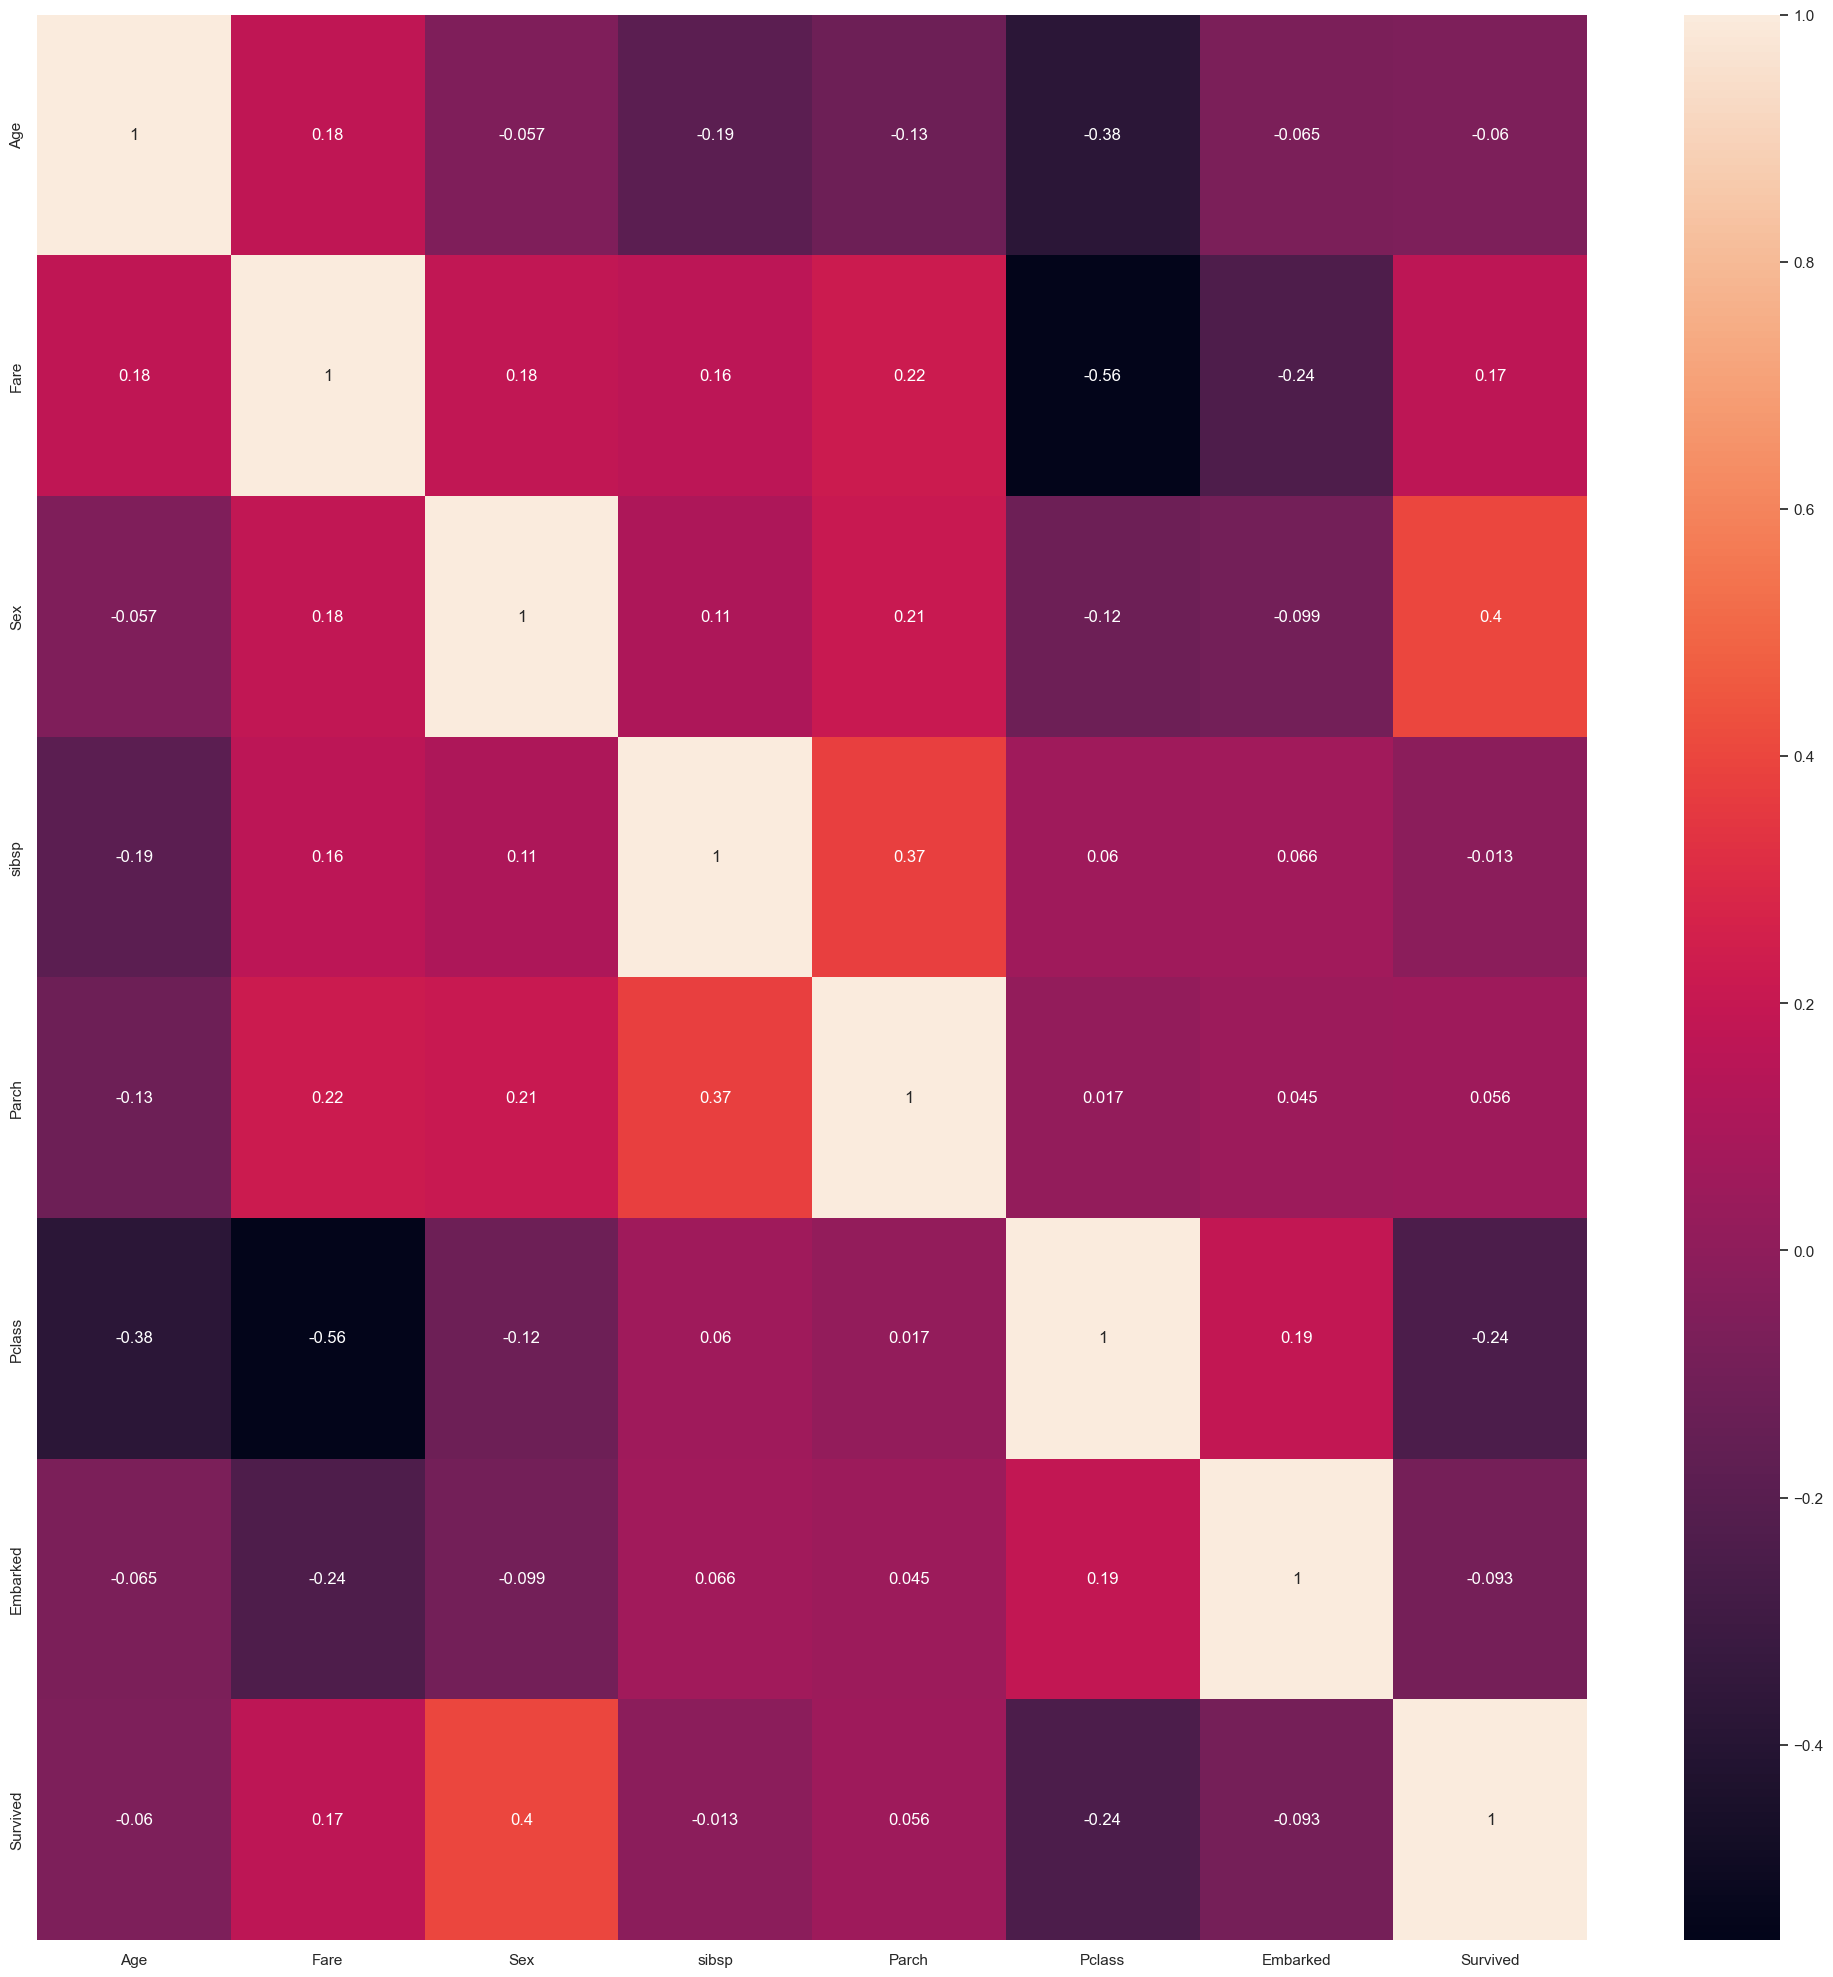

In [56]:
heat_map = sb.heatmap(df.corr() , annot=True )
sb.set(rc = {'figure.figsize':(25,25)})
plt.show()